In [1]:
import numpy as np
from scipy.linalg import eigh
from substructuring_function import fbs_coupling
import sdynpy as sdpy
%matplotlib qt
import matplotlib.pyplot as plt

## Creating the Lumped Parameter Systems

In [2]:
def compute_frf(mass, damping, stiffness, frequency, displacement_derivative=2):
    """
    Computes the FRFs from the supplied mass, stiffness, and damping matrices

    Parameters 
    ----------
    mass : ndarray
        The mass matrix as an ndarray.
    damping : ndarray
        The damping matrix as an ndarray.
    stiffness : ndarray
        The stiffness matrix as an ndarray.
    frequency : ndarray
        A 1d array of frequencies (in Hz) to evaluate the FRFs over.
    displacement_derivative : int, optional
        The derivative to compute the FRFs over. 0 results in compliance, 
        1 results in mobility, and 2 results in accelerance. The default is 
        accelerance. 

    Returns
    -------
    frf : ndarray
        The FRF matrix as an ndarray that is shaped [frequency, response, reference].
    """
    angular_frequency = (2*np.pi*frequency)[...,np.newaxis, np.newaxis]
    impedance = -mass[np.newaxis,...]*(angular_frequency**2) + 1j*damping[np.newaxis,...]*angular_frequency+stiffness
    if displacement_derivative == 0:
        frf = np.linalg.pinv(impedance)
    elif displacement_derivative == 1:
        frf = (1j*angular_frequency)*np.linalg.pinv(impedance)
    elif displacement_derivative == 2:
        frf = -(angular_frequency**2)*np.linalg.pinv(impedance)

    return frf

In [3]:
system_a_mass = np.array([[1, 0],
                          [0, 1]])

system_a_stiffness = np.array([[50000, -25000],
                               [-25000, 25000]])

system_a_damping = 0.1*system_a_mass+0.00001*system_a_stiffness

system_b_mass = np.array([[1, 0],
                          [0, 1]])

system_b_stiffness = np.array([[25000, -25000],
                               [-25000, 50000]])

system_b_damping = 0.1*system_b_mass+0.00001*system_b_stiffness

system_mass = np.array([[1, 0, 0],
                        [0, 2, 0],
                        [0, 0, 1]])

system_stiffness = np.array([[ 50000, -25000,  0],
                             [-25000,  50000, -25000],
                             [ 0,     -25000,  50000]])

system_damping = 0.1*system_mass+0.00001*system_stiffness

In [4]:
frequencies = np.arange(501)*0.05

system_a_frfs = compute_frf(system_a_mass, system_a_damping, system_a_stiffness, frequencies)
system_b_frfs = compute_frf(system_b_mass, system_b_damping, system_b_stiffness, frequencies)
system_frfs = compute_frf(system_mass, system_damping, system_stiffness, frequencies)

### Coupling with LM-FBS

In [5]:
block_diagonal_frf = np.zeros((system_a_frfs.shape[0], system_a_frfs.shape[1]+system_b_frfs.shape[1], system_a_frfs.shape[2]+system_b_frfs.shape[2]), dtype=complex)
block_diagonal_frf[:, :system_a_frfs.shape[1], :system_a_frfs.shape[2]] = system_a_frfs
block_diagonal_frf[:, system_a_frfs.shape[1]:, system_a_frfs.shape[2]:] = system_b_frfs

b = np.array([[0, 1, -1, 0]])

lm_fbs_frfs = fbs_coupling(block_diagonal_frf, b, b)

if np.allclose(system_frfs, lm_fbs_frfs):
    print('The LM-FBS FRFs exactly match the FRFs that were computed from system matrices')

The LM-FBS FRFs exactly match the FRFs that were computed from system matrices


### Coupling with the Algebraically Derived Equations
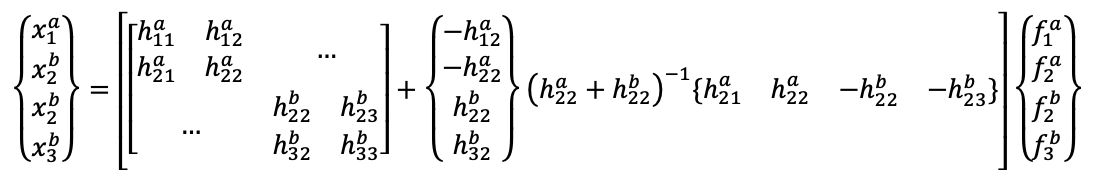

In [6]:
column_vector = np.concatenate((-block_diagonal_frf[:,0,1][...,np.newaxis], 
                                -block_diagonal_frf[:,1,1][...,np.newaxis], 
                                block_diagonal_frf[:,2,2][...,np.newaxis], 
                                block_diagonal_frf[:,3,2][...,np.newaxis]), axis=1)[...,np.newaxis]

row_vector = np.concatenate((block_diagonal_frf[:,1,0][...,np.newaxis], 
                             block_diagonal_frf[:,1,1][...,np.newaxis], 
                            -block_diagonal_frf[:,2,2][...,np.newaxis], 
                            -block_diagonal_frf[:,2,3][...,np.newaxis]), axis=1)[:,np.newaxis,:]

kernel = np.linalg.pinv((block_diagonal_frf[:,1,1]+block_diagonal_frf[:,2,2])[...,np.newaxis,np.newaxis])

algebraic_frfs = block_diagonal_frf + (column_vector@kernel@row_vector)
algebraic_frfs = np.delete(algebraic_frfs, 2, axis=1)
algebraic_frfs = np.delete(algebraic_frfs, 2, axis=2)

if np.allclose(system_frfs, algebraic_frfs):
    print('The algebraic FBS FRFs exactly match the FRFs that were computed from system matrices')

The algebraic FBS FRFs exactly match the FRFs that were computed from system matrices


In [7]:
"""
res_ind = 0
ref_ind = 0

fig, ax = plt.subplots(2)
ax[0].semilogy(frequencies, np.abs(system_frfs[:,res_ind,ref_ind]), linewidth=3)
ax[0].semilogy(frequencies, np.abs(lm_fbs_frfs[:,res_ind,ref_ind]), linestyle='--')
ax[0].semilogy(frequencies, np.abs(algebraic_frfs[:,res_ind,ref_ind]), linestyle=':')

ax[1].plot(frequencies, np.angle(system_frfs[:,res_ind,ref_ind]), linewidth=3)
ax[1].plot(frequencies, np.angle(lm_fbs_frfs[:,res_ind,ref_ind]), linestyle='--')
ax[1].plot(frequencies, np.angle(algebraic_frfs[:,res_ind,ref_ind]), linestyle=':')
"""

"\nres_ind = 0\nref_ind = 0\n\nfig, ax = plt.subplots(2)\nax[0].semilogy(frequencies, np.abs(system_frfs[:,res_ind,ref_ind]), linewidth=3)\nax[0].semilogy(frequencies, np.abs(lm_fbs_frfs[:,res_ind,ref_ind]), linestyle='--')\nax[0].semilogy(frequencies, np.abs(algebraic_frfs[:,res_ind,ref_ind]), linestyle=':')\n\nax[1].plot(frequencies, np.angle(system_frfs[:,res_ind,ref_ind]), linewidth=3)\nax[1].plot(frequencies, np.angle(lm_fbs_frfs[:,res_ind,ref_ind]), linestyle='--')\nax[1].plot(frequencies, np.angle(algebraic_frfs[:,res_ind,ref_ind]), linestyle=':')\n"